# Value Iteration

**Value Iteration** combines policy evaluation and improvement into a single update:

$$V_{k+1}(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right]$$

No explicit policy during the loop — we extract the policy once V converges.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc)); ns=nr*self.size+nc
        if (nr,nc)==self.goal:   return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits: return [(1.0,ns,-5.0,True)]
        return [(1.0,ns,-0.1,False)]

env = GridWorld()

In [2]:
def value_iteration(env, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    errors = []
    iteration = 0
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            Q_s = [sum(p*(r + (0 if d else gamma*V[ns]))
                       for p,ns,r,d in env.transitions(s,a))
                   for a in range(env.n_actions())]
            V_new[s] = max(Q_s)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        errors.append(delta)
        iteration += 1
        if delta < theta:
            print(f"Value iteration converged in {iteration} sweeps (Δ={delta:.2e})")
            break
    # Extract greedy policy
    policy = np.zeros(env.n_states(), dtype=int)
    for s in range(env.n_states()):
        Q_s = [sum(p*(r + (0 if d else gamma*V[ns]))
                   for p,ns,r,d in env.transitions(s,a))
               for a in range(env.n_actions())]
        policy[s] = np.argmax(Q_s)
    return V, policy, errors

V_star, pi_star, errors = value_iteration(env)

Value iteration converged in 9 sweeps (Δ=0.00e+00)


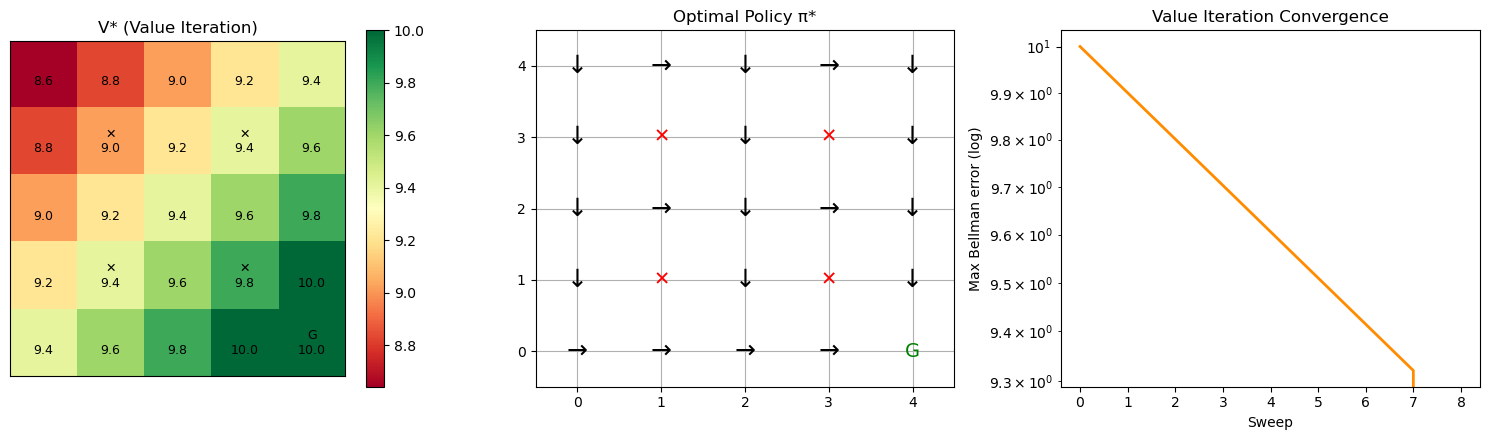

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Value function
im = axes[0].imshow(V_star.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for s in range(25):
    r,c=divmod(s,5)
    label='G' if (r,c)==env.goal else ('✕' if (r,c) in env.pits else '')
    axes[0].text(c,r,f'{label}\n{V_star[s]:.1f}',ha='center',va='center',fontsize=9)
axes[0].set_title('V* (Value Iteration)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Optimal policy
axes[1].set_xlim(-0.5,4.5); axes[1].set_ylim(-0.5,4.5)
axes[1].set_xticks(range(5)); axes[1].set_yticks(range(5)); axes[1].grid(True)
for s in range(25):
    r,c=divmod(s,5)
    if (r,c)==env.goal:         axes[1].text(c,4-r,'G',ha='center',va='center',fontsize=14,color='green')
    elif (r,c) in env.pits:     axes[1].text(c,4-r,'✕',ha='center',va='center',fontsize=14,color='red')
    else:                       axes[1].text(c,4-r,env.ACTION_SYMBOLS[pi_star[s]],ha='center',va='center',fontsize=18)
axes[1].set_title('Optimal Policy π*')

# Convergence
axes[2].semilogy(errors, color='darkorange', linewidth=2)
axes[2].set_xlabel('Sweep'); axes[2].set_ylabel('Max Bellman error (log)')
axes[2].set_title('Value Iteration Convergence')
plt.tight_layout(); plt.show()

## Policy Iteration vs Value Iteration — Comparison

In [4]:
import time

# Time value iteration
t0 = time.time()
for _ in range(20): value_iteration(env)
vi_time = (time.time()-t0)/20

print(f"Value Iteration avg time: {vi_time*1000:.2f} ms")
print(f"\nKey difference:")
print(" Policy Iteration: full eval to convergence at each step (many inner loops)")
print(" Value Iteration:  single sweep per iteration (simpler inner loop)")
print(" Both converge to the same optimal policy.")

Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 